In [ ]:
# Images from https://github.com/credo-science/image-data-set.git
# %pip install opencv-python==4.6.0.66
# %pip install torch torchvision
# %conda install -c conda-forge onnx

In [1]:
import tarfile
import os
datasets = ['artefacts', 'dots', 'tracks', 'worms']
base_dir = "./muon_dataset"

# ### Uncomment these for first time to extract files
# Extract each tarball into its own sub-folder
# for ds in datasets:
#     tar_path = f"{ds}.tar.gz"
#     if os.path.exists(tar_path):
#         print(f"Extracting {tar_path}...")
#         with tarfile.open(tar_path, "r:gz") as tar:
#             tar.extractall(path=os.path.join(base_dir, ds))
#     else:
#         print(f"Warning: Could not find {tar_path} in the current directory.")


In [2]:
import cv2
import numpy as np

# Size of my images
TARGET_SIZE = (60, 60)

def preprocess_muon_image(image_path, target_size=TARGET_SIZE):
    """
    Automatically converts any image to grayscale and safely pads/scales 
    it to the target size without warping structural physics tracks.
    """
    # Load image in grayscale immediately
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image at {image_path}")
        
    h, w = img.shape
    th, tw = target_size
    
    # Case A: Perfect match -> Do nothing
    if (h, w) == (th, tw):
        processed_img = img
        
    # Case B: Image is smaller -> Apply Smart Zero-Padding
    elif h <= th and w <= tw:
        pad_vert = th - h
        pad_horz = tw - w
        top = pad_vert // 2
        bottom = pad_vert - top
        left = pad_horz // 2
        right = pad_horz - left
        processed_img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=0)
        
    # Case C: Image is larger -> Safely Downsample
    else:
        # Protects edge contrasts better for dark backgrounds than bilinear interpolation
        processed_img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
        
    # Normalize pixel values to [0.0, 1.0] for the model
    normalized_img = processed_img.astype(np.float32) / 255.0
    
    return normalized_img


In [3]:
print("\n--- Dataset Distribution Summary ---")
class_counts = []
for ds in datasets:
    folder_path = os.path.join(base_dir, ds, ds) # dir is like dots/dots/*.png
    if os.path.exists(folder_path):
        # Recursively count all image files inside the extracted directories
        num_images = sum([len(files) for r, d, files in os.walk(folder_path) if \
                          any(f.endswith(('.png', '.jpg', '.jpeg', '.bmp')) for f in files)])
        class_counts.append(num_images)
        print(f"Class '{ds}': {num_images} images found")



--- Dataset Distribution Summary ---
Class 'artefacts': 5335 images found
Class 'dots': 6567 images found
Class 'tracks': 5839 images found
Class 'worms': 762 images found


In [4]:
import os
import glob
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torchvision.transforms.v2 as v2

# safe augmentations FOR TRAINING ONLY
# train_transforms = v2.Compose([
#     v2.RandomHorizontalFlip(p=0.5),
#     v2.RandomVerticalFlip(p=0.5),
#     v2.RandomRotation(degrees=(0, 360), interpolation=v2.InterpolationMode.NEAREST),
# ])

class MuonDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        """
        Accepts explicit lists of file paths and labels so train/val splits 
        are kept strictly separated.
        """
        self.file_list = file_list
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.file_list)
        
    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        processed_numpy_img = preprocess_muon_image(img_path, target_size=(60, 60))
        
        # Convert numpy array (H, W) to PyTorch tensor format (1, H, W)
        tensor_img = torch.tensor(processed_numpy_img, dtype=torch.float32).unsqueeze(0)
        
        # Apply augmentations ONLY if transform is passed
        if self.transform:
            tensor_img = self.transform(tensor_img)
            
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return tensor_img, label

def create_muon_dataloaders(base_dir, batch_size=32, val_ratio=0.2, random_seed=42):
    """
    Scans files, performs a stratified, fixed split using a random seed, 
    and returns separate train_loader and val_loader.
    """
    classes = ['artefacts', 'dots', 'tracks', 'worms']
    all_files = []
    all_labels = []

    # Gather all file paths and class labels
    for class_idx, class_name in enumerate(classes):
        search_path = os.path.join(base_dir, class_name, class_name, "**", "*.*")
        for file_path in glob.glob(search_path, recursive=True):
            if file_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                all_files.append(file_path)
                all_labels.append(class_idx)

    # Stratified, fixed random split (preserves class balance across train & val)
    train_files, val_files, train_labels, val_labels = train_test_split(
        all_files, 
        all_labels, 
        test_size=val_ratio, 
        random_state=random_seed,  # Ensures exact same split every training run
        stratify=all_labels
    )

    # Create Train Dataset WITH augmentations
    # train_dataset = MuonDataset(train_files, train_labels, transform=train_transforms)
    train_dataset = MuonDataset(train_files, train_labels,)
    
    # Create Validation Dataset WITHOUT augmentations
    val_dataset = MuonDataset(val_files, val_labels, transform=None)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    print(f"Dataset Split Complete (Seed {random_seed}):")
    print(f" -> Training Samples   : {len(train_dataset)} (Augmented)")
    print(f" -> Validation Samples : {len(val_dataset)} (Clean / Unaugmented)")

    return train_loader, val_loader

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# train_dataset = MuonDataset(base_dir="./muon_dataset")
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
train_loader, val_loader = create_muon_dataloaders(base_dir="./muon_dataset", batch_size=32)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class MuonMiniCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(MuonMiniCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.3)
        self.fc_out = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc_out(x) 


# Instantiate the model
model = MuonMiniCNN()
print("Dataset loaded and Model Architecture built successfully!")


Dataset Split Complete (Seed 42):
 -> Training Samples   : 14800 (Augmented)
 -> Validation Samples : 3701 (Clean / Unaugmented)
Dataset loaded and Model Architecture built successfully!


In [6]:
# Test a single data pass
try:
    images, labels = next(iter(train_loader))
    print(f"Batch image tensor shape: {images.shape}")  # Should be [32, 1, 60, 60]
    print(f"Batch label tensor shape: {labels.shape}")  # Should be [32]
    
    # Pass through model
    outputs = model(images)
    print(f"Model output tensor shape: {outputs.shape}") # Should be [32, 4]
    print(" Everything is working perfectly! Ready for training.")
except Exception as e:
    print(f" An error occurred: {e}")
    print("Check if the tarballs were fully extracted in the correct directory path.")


Batch image tensor shape: torch.Size([32, 1, 60, 60])
Batch label tensor shape: torch.Size([32])
Model output tensor shape: torch.Size([32, 4])
 Everything is working perfectly! Ready for training.


In [8]:
import torch.optim as optim
import os

# Device selection (Uses GPU/CUDA if available, otherwise falls back to CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Move model to the selected device
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
print("Starting training with independent binary thresholds...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        # Convert integer class indices (e.g. 2) to multi-hot floats (e.g.)
        labels_one_hot = F.one_hot(labels, num_classes=4).float().to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)  # Outputs raw logits
        loss = criterion(outputs, labels_one_hot)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        # Performance Evaluation: Convert outputs to independent probabilities via Sigmoid
        probs = torch.sigmoid(outputs)
        
        # An item is correct if its highest probability matches the label, 
        # but only if it passes a minimum threshold (e.g., 0.60)
        max_probs, predicted = torch.max(probs, 1)
        
        # If the max probability is below 0.60, classify it as "artefacts" (index 0)
        predicted = torch.where(max_probs >= 0.60, predicted, torch.zeros_like(predicted))
        
        total += labels.size(0)
        correct += (predicted == labels.to(device)).sum().item()
        
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = (correct / total) * 100
    print(f"Epoch [{epoch+1}/{epochs}] -> Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")


# Save Native PyTorch Weights
torch.save(model.state_dict(), "muon_mini_cnn_bce.pth")
print("Saved PyTorch weights as 'muon_mini_cnn_bce.pth'")

# Export to ONNX for SBC Deployment
model.eval()
dummy_input = torch.randn(1, 1, 60, 60).to(device)

torch.onnx.export(
    model, 
    dummy_input, 
    "muon_model_bce.onnx", 
    export_params=True, 
    opset_version=12, 
    input_names=['input'], 
    output_names=['output']
)

print("Saved lightweight deployment model as 'muon_model_bce.onnx'!")


Training on device: cpu
Starting training with independent binary thresholds...
Epoch [1/10] -> Loss: 0.3102 | Accuracy: 58.69%
Epoch [2/10] -> Loss: 0.1732 | Accuracy: 85.43%
Epoch [3/10] -> Loss: 0.1365 | Accuracy: 89.01%
Epoch [4/10] -> Loss: 0.1261 | Accuracy: 89.74%
Epoch [5/10] -> Loss: 0.1159 | Accuracy: 90.48%
Epoch [6/10] -> Loss: 0.1090 | Accuracy: 91.01%
Epoch [7/10] -> Loss: 0.1048 | Accuracy: 91.30%
Epoch [8/10] -> Loss: 0.1019 | Accuracy: 91.34%
Epoch [9/10] -> Loss: 0.0924 | Accuracy: 91.89%
Epoch [10/10] -> Loss: 0.0894 | Accuracy: 92.18%
Saved PyTorch weights as 'muon_mini_cnn_bce.pth'
Saved lightweight deployment model as 'muon_model_bce.onnx'!


In [19]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, 
    roc_curve, 
    roc_auc_score, 
    average_precision_score, 
    matthews_corrcoef,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

def evaluate_model_comprehensive(
    model, 
    val_loader, 
    fname="comprehensive", 
    class_names=['artefacts', 'dots', 'tracks', 'worms'], 
    device="cpu"
):
    model.eval()
    all_probs = []
    all_preds = []
    all_targets = []

    with torch.inference_mode():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            logits = model(inputs)
            probs = torch.nn.functional.softmax(logits, dim=1)
            _, preds = torch.max(logits, dim=1)
            
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_targets.append(targets.numpy())

    all_probs = np.vstack(all_probs)
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)


    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    colors = ['#d62728', '#2ca02c', '#1f77b4', '#9467bd']
    mcc_thresholds = np.linspace(0.01, 0.99, 100)
    
    best_thresholds = {}
    metrics_summary = {}

    for idx, name in enumerate(class_names):
        binary_targets = (all_targets == idx).astype(int)
        class_probs = all_probs[:, idx]

        # PR and AP
        precision, recall, _ = precision_recall_curve(binary_targets, class_probs)
        ap_score = average_precision_score(binary_targets, class_probs)
        axes[0, 0].plot(recall, precision, color=colors[idx], lw=2, label=f"{name} (AP={ap_score:.3f})")

        # ROC and AUC
        fpr, tpr, _ = roc_curve(binary_targets, class_probs)
        roc_auc = roc_auc_score(binary_targets, class_probs)
        axes[1, 1].plot(fpr, tpr, color=colors[idx], lw=2, label=f"{name} (AUC={roc_auc:.3f})")

        # MCC Sweep
        mcc_scores = [matthews_corrcoef(binary_targets, (class_probs >= t).astype(int)) for t in mcc_thresholds]
        best_idx = np.argmax(mcc_scores)
        best_thresh, best_mcc = mcc_thresholds[best_idx], mcc_scores[best_idx]
        
        best_thresholds[name] = float(best_thresh)
        metrics_summary[name] = {"threshold": float(best_thresh), "mcc": float(best_mcc), "roc_auc": float(roc_auc), "ap_score": float(ap_score)}

        axes[1, 0].plot(mcc_thresholds, mcc_scores, color=colors[idx], lw=2, label=f"{name} (Tau={best_thresh:.2f})")
        axes[1, 0].axvline(best_thresh, color=colors[idx], linestyle="--", alpha=0.4)

    # Precision-Recall (Top-Left)
    axes[0, 0].set_title("OvR Precision-Recall Curves", fontsize=11)
    axes[0, 0].set_xlabel("Recall")
    axes[0, 0].set_ylabel("Precision")
    axes[0, 0].grid(True, linestyle="--", alpha=0.6)
    axes[0, 0].legend(loc="lower left", fontsize=8)

    # Confusion Matrix (Top-Right)
    cm = confusion_matrix(all_targets, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[0, 1], cmap='Blues', colorbar=False, xticks_rotation=45)
    axes[0, 1].set_title("Multiclass Confusion Matrix", fontsize=11)

    # MCC vs Threshold (Bottom-Left)
    axes[1, 0].set_title("OvR MCC vs. Decision Threshold", fontsize=11)
    axes[1, 0].set_xlabel("Threshold (Tau)")
    axes[1, 0].set_ylabel("MCC Score")
    axes[1, 0].grid(True, linestyle="--", alpha=0.6)
    axes[1, 0].legend(loc="lower center", fontsize=8)

    # ROC Curves (Bottom-Right)
    axes[1, 1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random")
    axes[1, 1].set_title("OvR ROC Curves", fontsize=11)
    axes[1, 1].set_xlabel("False Positive Rate")
    axes[1, 1].set_ylabel("True Positive Rate")
    axes[1, 1].grid(True, linestyle="--", alpha=0.6)
    axes[1, 1].legend(loc="lower right", fontsize=8)

    os.makedirs('figs', exist_ok=True)
    plt.tight_layout()
    plt.savefig(f'figs/metrics_{fname}.png', dpi=200, bbox_inches='tight')
    plt.show()

    overall_mcc = matthews_corrcoef(all_targets, all_preds)
    print("\n================ Classification Report ================")
    print(classification_report(all_targets, all_preds, target_names=class_names))
    print(f"Overall Multiclass MCC: {overall_mcc:.4f}\n")
    
    print("=== Optimal Class Thresholds ===")
    for name, m in metrics_summary.items():
        print(f"Class '{name:10s}': Tau = {m['threshold']:.2f} | MCC = {m['mcc']:.3f} | AP = {m['ap_score']:.3f} | AUC = {m['roc_auc']:.3f}")

    return best_thresholds, metrics_summary

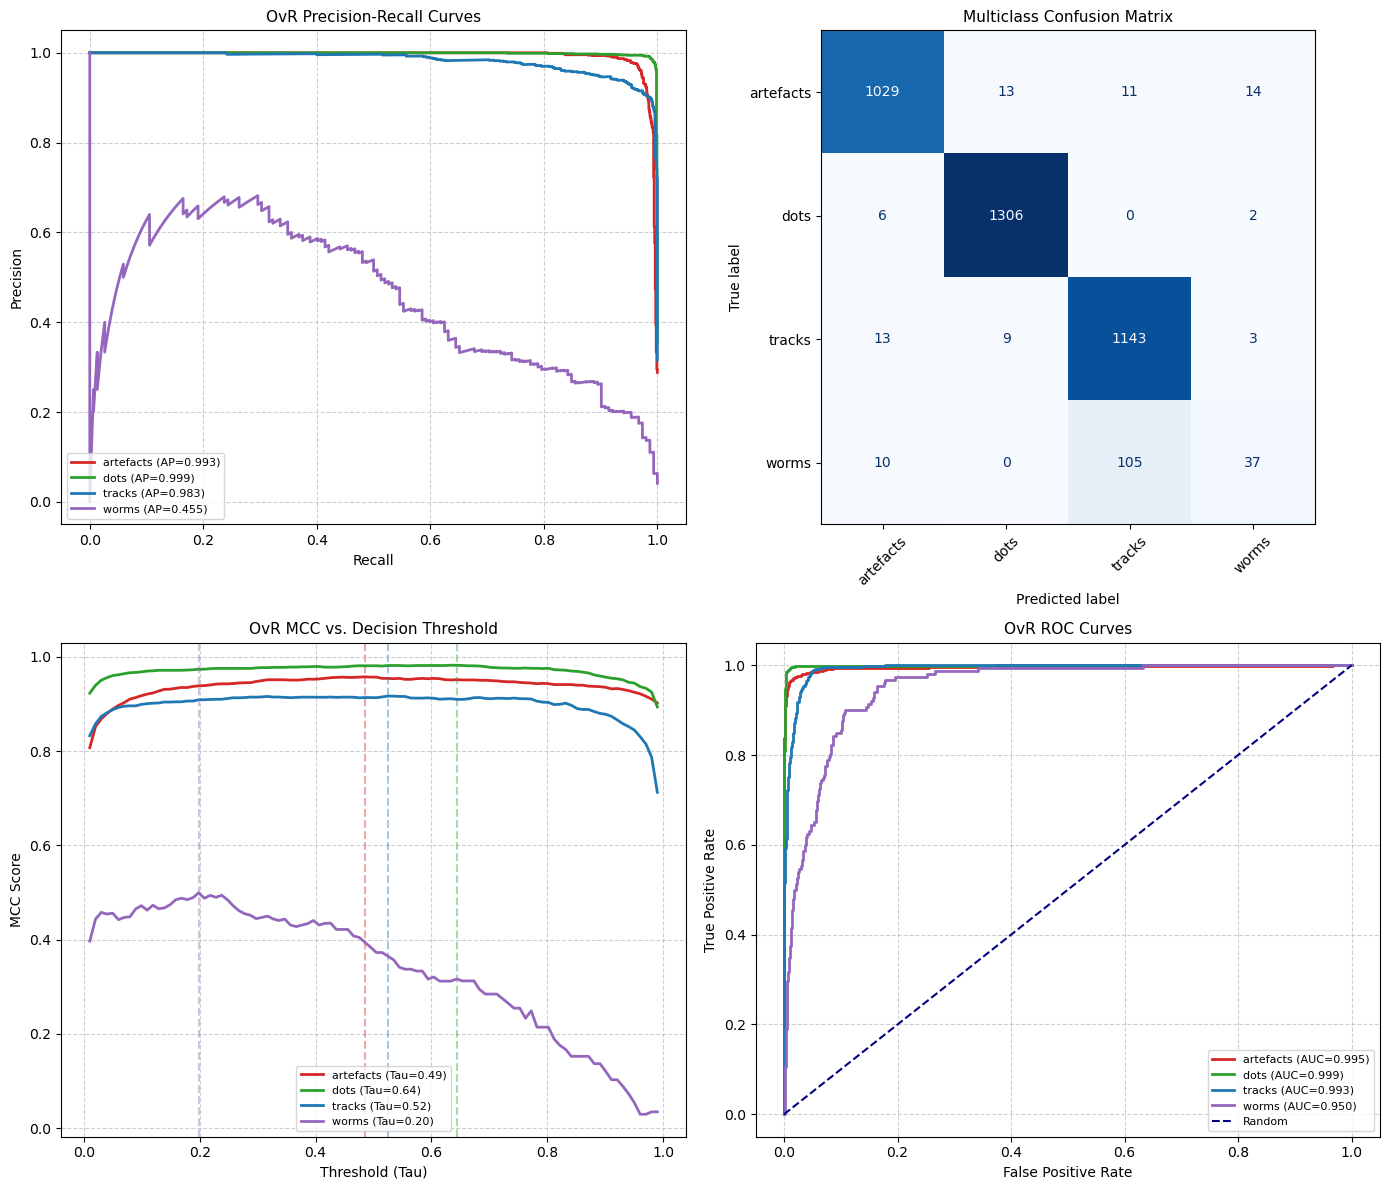


================ Classification Report ================
              precision    recall  f1-score   support

   artefacts       0.97      0.96      0.97      1067
        dots       0.98      0.99      0.99      1314
      tracks       0.91      0.98      0.94      1168
       worms       0.66      0.24      0.36       152

    accuracy                           0.95      3701
   macro avg       0.88      0.80      0.81      3701
weighted avg       0.94      0.95      0.94      3701

Overall Multiclass MCC: 0.9273

=== Optimal Class Thresholds ===
Class 'artefacts ': Tau = 0.49 | MCC = 0.958 | AP = 0.993 | AUC = 0.995
Class 'dots      ': Tau = 0.64 | MCC = 0.982 | AP = 0.999 | AUC = 0.999
Class 'tracks    ': Tau = 0.52 | MCC = 0.917 | AP = 0.983 | AUC = 0.993
Class 'worms     ': Tau = 0.20 | MCC = 0.499 | AP = 0.455 | AUC = 0.950


In [22]:
THRESHOLDS, metrics = evaluate_model_comprehensive(model, val_loader, 'muon_mini_bce')

In [23]:
THRESHOLDS

{'artefacts': 0.4851515151515151,
 'dots': 0.6435353535353535,
 'tracks': 0.5247474747474747,
 'worms': 0.19808080808080808}

In [24]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

import torch


def classify_particle_batch_with_percentages(tensors_list, model, device):
    """
    Runs batch inference using dynamic, optimized MCC thresholds derived from 
    validation tuning to resolve target class imbalances natively.
    """
    model.eval()
    CLASSES = ['artefacts', 'dots', 'tracks', 'worms']
    
    # Map the exact optimal thresholds found in validation tuning sweep
    OPTIMAL_THRESHOLDS = THRESHOLDS
    
    batch_tensor = torch.stack(tensors_list).to(device)
    
    with torch.inference_mode():
        logits = model(batch_tensor)  # Shape: [N, 4]
        
    # Convert logits to individual probabilities via Sigmoid
    probabilities = torch.sigmoid(logits).cpu()  # Shape: [N, 4]
    
    results = []
    for i in range(len(tensors_list)):
        item_probs = probabilities[i]
        
        passed_classes = []
        for idx, name in enumerate(CLASSES):
            prob = item_probs[idx].item()
            # Verify if the individual probability passes its dedicated threshold
            if prob >= OPTIMAL_THRESHOLDS[name]:
                passed_classes.append((idx, name, prob))
        
        if not passed_classes:
            # Fall back to 'artefacts' if no class passes its minimum barrier
            winning_class = 'artefacts'
            winning_percentage = item_probs[0].item() * 100
        else:
            # Resolve conflicts if multiple categories pass their respective thresholds
            # Select the class that exceeded its threshold by the largest margin
            passed_classes.sort(key=lambda x: x[2] - OPTIMAL_THRESHOLDS[x[1]], reverse=True)
            winning_idx, winning_class, winning_prob = passed_classes[0]
            winning_percentage = winning_prob * 100
            
        results.append((winning_class, winning_percentage))
        
    return results



image_paths = ["../../Downloads/muons_test/worms_1789974646.png", "../../Downloads/muons_test/worms_1789974647.png", \
              "../../Downloads/muons_test/tracks_1789977878.png"]

true_labels = ['tracks', 'tracks', 'worm']
tensors_list = []
tensors_list = []

for path in image_paths:
    img_np = preprocess_muon_image(path)
    img_tensor = torch.from_numpy(img_np).unsqueeze(0) # Shape: [1, 60, 60]
    tensors_list.append(img_tensor)

predictions = classify_particle_batch_with_percentages(tensors_list, model, device)


print("\n=== Cosmic Ray Event Detections ===")
for path, (pred_class, percentage) in zip(image_paths, predictions):
    print(f"File: {path}")
    print(f"  ↳ Identified As: {pred_class.upper()}")
    print(f"  ↳ Looks like: {true_labels[image_paths.index(path)]}")
    print(f"  ↳ Confidence    : {percentage:.2f}%")




=== Cosmic Ray Event Detections ===
File: ../../Downloads/muons_test/worms_1789974646.png
  ↳ Identified As: TRACKS
  ↳ Looks like: tracks
  ↳ Confidence    : 99.99%
File: ../../Downloads/muons_test/worms_1789974647.png
  ↳ Identified As: TRACKS
  ↳ Looks like: tracks
  ↳ Confidence    : 99.97%
File: ../../Downloads/muons_test/tracks_1789977878.png
  ↳ Identified As: WORMS
  ↳ Looks like: worm
  ↳ Confidence    : 27.38%
